# 02 — Limpeza do CNES (Hospitais e Leitos 2025)

**Projeto Aplicado II — Guilherme Cunha Oliveira (RA 10754621) e Gabriel Lucca Simionato (RA 10751300)**

Notebook nas 10 seções do *Plano de Limpeza das Bases*. Entrada preservada em `db/bases_brutas/cnes/`; saída em `db/bases_tratadas/cnes/`.

## 1. Objetivo

Transformar o cadastro de leitos por estabelecimento e competência em **indicadores municipais de infraestrutura de saúde**, com a granularidade prevista na seção 4 do plano — uma linha por `cod_municipio` e `competencia`, com `leitos`, `leitos_sus` e `leitos_uti` — compatível com a integração posterior ao SINAN pela chave territorial de 6 dígitos e pela competência derivada da data dos primeiros sintomas. Leitos cadastrados serão lidos como capacidade instalada, não como leitos livres nem como existência de hospital acessível.

In [1]:
# ============================================================
# 1. OBJETIVO
# ============================================================
ENTRADA_PREVISTA = "db/bases_brutas/cnes/Leitos_2025.csv"
SAIDA_PREVISTA   = "db/bases_tratadas/cnes/cnes_municipio_2025_tratado.csv"

## 2. Bibliotecas

In [2]:
# ============================================================
# 2. BIBLIOTECAS
# ============================================================
import json, hashlib, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore"); plt.rcParams.update({"axes.grid": True, "grid.alpha": .3})
pd.set_option("display.width", 160, "display.max_columns", 50)
print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 3.0.2 | numpy 2.4.4


## 3. Caminhos

In [3]:
# ============================================================
# 3. CAMINHOS
# ============================================================
RAIZ = Path("..").resolve()
BRUTA, TRATADA = RAIZ/"db/bases_brutas/cnes", RAIZ/"db/bases_tratadas/cnes"
TRATADA.mkdir(parents=True, exist_ok=True)
ARQ_BRUTO   = BRUTA/"Leitos_2025.csv"
ARQ_TRATADO = TRATADA/"cnes_municipio_2025_tratado.csv"
ARQ_ESTAB   = TRATADA/"cnes_estabelecimentos_2025_validado.csv"
ARQ_LOG     = TRATADA/"cnes_limpeza_log.json"
LOG = {"entrada": str(ARQ_BRUTO.relative_to(RAIZ)), "saida": str(ARQ_TRATADO.relative_to(RAIZ)), "etapas": {}}
print("entrada existe:", ARQ_BRUTO.exists())

entrada existe: True


## 4. Carregamento

O arquivo usa `;` como separador e codificação latin-1 (diferente do SINAN). Lemos tudo como texto para que a validação de tipos (seção 5) seja explícita, e registramos a identidade do arquivo.

In [4]:
# ============================================================
# 4. CARREGAMENTO
# ============================================================
def sha256(p):
    h = hashlib.sha256()
    with open(p, "rb") as f:
        for parte in iter(lambda: f.read(1 << 24), b""): h.update(parte)
    return h.hexdigest()
cab = open(ARQ_BRUTO, "rb").read(2048)
try: cab.decode("utf-8"); encoding = "utf-8"
except UnicodeDecodeError: encoding = "latin-1"
separador = max([",", ";", "\t"], key=lambda s: cab.split(b"\n")[0].count(s.encode()))
LOG["etapas"]["identidade"] = {"tamanho_MB": round(ARQ_BRUTO.stat().st_size/1e6, 1), "sha256": sha256(ARQ_BRUTO), "encoding": encoding, "separador": separador}
leitos = pd.read_csv(ARQ_BRUTO, sep=separador, encoding=encoding, dtype=str)
print(json.dumps(LOG["etapas"]["identidade"], indent=2)); print("shape:", leitos.shape)
leitos.head(3).T

{
  "tamanho_MB": 28.7,
  "sha256": "bbb924a621165230dabc915e164f01b19d25baa83735bc57f0051643f313edd5",
  "encoding": "latin-1",
  "separador": ";"
}
shape: (86147, 35)


,0,1,2
COMP,202501,202501,202501
REGIAO,NORDESTE,NORDESTE,NORDESTE
UF,PE,PE,PE
CO_IBGE,260290,260290,260290
MUNICIPIO,CABO DE SANTO AGOSTINHO,CABO DE SANTO AGOSTINHO,CABO DE SANTO AGOSTINHO
MOTIVO_DESABILITACAO,NaN,NaN,NaN
CNES,0000027,0000035,0000094
NOME_ESTABELECIMENTO,CASA DE SAUDE SANTA HELENA,HOSPITAL MENDO SAMPAIO,MATERNIDADE PADRE GERALDO LEITE BASTOS
RAZAO_SOCIAL,CASA DE SAUDE E MATERNIDADE SANTA HELENA LTDA,PREFEITURA MUNICIPAL DO CABO DE SANTO AGOSTINHO,PREFEITURA MUNICIPAL DO CABO DE SANTO AGOSTINHO
TP_GESTAO,M,M,M


## 5. Diagnóstico inicial

Dimensões, tipos, nulos, códigos, duplicidades e problemas: competências presentes, formato do código municipal, unicidade de estabelecimento por competência, categorias de leito e valores das colunas numéricas.

In [5]:
# ============================================================
# 5. DIAGNÓSTICO INICIAL
# ============================================================
COLS_LEITO = [c for c in leitos.columns if c.startswith(("LEITOS_", "UTI_"))]
diag = pd.DataFrame({"nulos_%": (leitos.isna().mean()*100).round(2), "n_distintos": leitos.nunique(), "exemplo": leitos.iloc[0].astype(str).str[:25]})
print(diag.to_string())

                        nulos_%  n_distintos                    exemplo
COMP                       0.00           12                     202501
REGIAO                     0.00            5                   NORDESTE
UF                         0.00           27                         PE
CO_IBGE                    0.00         3577                     260290
MUNICIPIO                  0.00         3435    CABO DE SANTO AGOSTINHO
MOTIVO_DESABILITACAO     100.00            0                        NaN
CNES                       0.00         7369                    0000027
NOME_ESTABELECIMENTO       0.00         7052  CASA DE SAUDE SANTA HELEN
RAZAO_SOCIAL               0.00         6148  CASA DE SAUDE E MATERNIDA
TP_GESTAO                  0.00            3                          M
CO_TIPO_UNIDADE            0.00            5                         05
DS_TIPO_UNIDADE            0.00            5             HOSPITAL GERAL
NATUREZA_JURIDICA          0.00           31                    

In [6]:
print("competências (COMP):", leitos.COMP.value_counts().sort_index().to_dict())
print("CO_IBGE — n dígitos:", leitos.CO_IBGE.str.len().value_counts().to_dict(), "| só dígitos:", leitos.CO_IBGE.str.fullmatch(r"\d+").all())
print("CNES — n dígitos:", leitos.CNES.str.len().value_counts().to_dict())
print("estabelecimentos distintos:", leitos.CNES.nunique(), "| municípios distintos:", leitos.CO_IBGE.nunique())
print("linhas duplicadas por (COMP, CNES):", int(leitos.duplicated(["COMP","CNES"]).sum()), "| linhas totalmente duplicadas:", int(leitos.duplicated().sum()))
print("MOTIVO_DESABILITACAO preenchido:", int(leitos.MOTIVO_DESABILITACAO.notna().sum()))
print("\nDS_TIPO_UNIDADE:"); print(leitos.DS_TIPO_UNIDADE.value_counts().to_string())
print("\nDESC_NATUREZA_JURIDICA:"); print(leitos.DESC_NATUREZA_JURIDICA.value_counts().to_string())
print("\nTP_GESTAO:", leitos.TP_GESTAO.value_counts(dropna=False).to_dict())

competências (COMP): {'202501': 7149, '202502': 7152, '202503': 7165, '202504': 7168, '202505': 7177, '202506': 7176, '202507': 7187, '202508': 7187, '202509': 7195, '202510': 7190, '202511': 7198, '202512': 7203}
CO_IBGE — n dígitos: {6: 86147} | só dígitos: True
CNES — n dígitos: {7: 86147}
estabelecimentos distintos: 7369 | municípios distintos: 3577


linhas duplicadas por (COMP, CNES): 0 | linhas totalmente duplicadas: 0
MOTIVO_DESABILITACAO preenchido: 0

DS_TIPO_UNIDADE:
DS_TIPO_UNIDADE
HOSPITAL GERAL                  66126
HOSPITAL ESPECIALIZADO          12514
UNIDADE MISTA                    6197
PRONTO SOCORRO GERAL              988
PRONTO SOCORRO ESPECIALIZADO      322

DESC_NATUREZA_JURIDICA:
DESC_NATUREZA_JURIDICA
HOSPITAL_PÚBLICO         39299
HOSPITAL_PRIVADO         24844
HOSPITAL_FILANTRÓPICO    22004

TP_GESTAO: {'M': 62675, 'E': 15469, 'D': 8003}


In [7]:
num = leitos[COLS_LEITO].apply(pd.to_numeric, errors="coerce")
print("valores não numéricos por coluna de leito:", (num.isna() & leitos[COLS_LEITO].notna()).sum().to_dict())
print("nulos:", num.isna().sum().to_dict())
print(num.describe().round(1).T.to_string())
print("\nConsistência entre categorias:")
print("  LEITOS_SUS > LEITOS_EXISTENTES:", int((num.LEITOS_SUS > num.LEITOS_EXISTENTES).sum()))
print("  UTI_TOTAL_EXIST > LEITOS_EXISTENTES:", int((num.UTI_TOTAL_EXIST > num.LEITOS_EXISTENTES).sum()))
print("  UTI_TOTAL_SUS > UTI_TOTAL_EXIST:", int((num.UTI_TOTAL_SUS > num.UTI_TOTAL_EXIST).sum()))
print("  UTI_TOTAL_EXIST != soma das UTIs por tipo:", int((num.UTI_TOTAL_EXIST != num[["UTI_ADULTO_EXIST","UTI_PEDIATRICO_EXIST","UTI_NEONATAL_EXIST","UTI_QUEIMADO_EXIST","UTI_CORONARIANA_EXIST"]].sum(axis=1)).sum()))
print("  valores negativos:", int((num < 0).sum().sum()), "| LEITOS_EXISTENTES = 0:", int((num.LEITOS_EXISTENTES == 0).sum()))

valores não numéricos por coluna de leito: {'LEITOS_EXISTENTES': 0, 'LEITOS_SUS': 0, 'UTI_TOTAL_EXIST': 0, 'UTI_TOTAL_SUS': 0, 'UTI_ADULTO_EXIST': 0, 'UTI_ADULTO_SUS': 0, 'UTI_PEDIATRICO_EXIST': 0, 'UTI_PEDIATRICO_SUS': 0, 'UTI_NEONATAL_EXIST': 0, 'UTI_NEONATAL_SUS': 0, 'UTI_QUEIMADO_EXIST': 0, 'UTI_QUEIMADO_SUS': 0, 'UTI_CORONARIANA_EXIST': 0, 'UTI_CORONARIANA_SUS': 0}
nulos: {'LEITOS_EXISTENTES': 0, 'LEITOS_SUS': 0, 'UTI_TOTAL_EXIST': 0, 'UTI_TOTAL_SUS': 0, 'UTI_ADULTO_EXIST': 0, 'UTI_ADULTO_SUS': 0, 'UTI_PEDIATRICO_EXIST': 0, 'UTI_PEDIATRICO_SUS': 0, 'UTI_NEONATAL_EXIST': 0, 'UTI_NEONATAL_SUS': 0, 'UTI_QUEIMADO_EXIST': 0, 'UTI_QUEIMADO_SUS': 0, 'UTI_CORONARIANA_EXIST': 0, 'UTI_CORONARIANA_SUS': 0}
                         count  mean   std  min   25%   50%   75%     max
LEITOS_EXISTENTES      86147.0  72.4  95.3  1.0  20.0  41.0  87.0  1543.0
LEITOS_SUS             86147.0  48.9  82.2  0.0   1.0  24.0  56.0  1476.0
UTI_TOTAL_EXIST        86147.0   9.0  19.8  0.0   0.0   0.0  10.0   

Leitura do diagnóstico: as 12 competências de 2025 estão presentes, com cerca de 7,2 mil estabelecimentos em cada uma; nenhum par (competência, CNES) se repete; o código municipal tem 6 dígitos numéricos, compatível com `ID_MN_RESI` do SINAN; `MOTIVO_DESABILITACAO` está vazio em todas as linhas (só estabelecimentos ativos); as colunas de leito são inteiras, sem nulos nem negativos, e as relações esperadas entre categorias (SUS ≤ existentes, UTI ≤ leitos, UTI total = soma das UTIs por tipo) são verificadas na célula acima. Os campos de endereço, telefone e e-mail não têm papel no projeto.

## 6. Regras de limpeza

- **R1 — Tipos.** `COMP` → inteiro AAAAMM; colunas de leito → inteiros; demais identificadores permanecem texto.
- **R2 — Código municipal.** `CO_IBGE` → `cod_municipio`, texto com 6 dígitos (zero à esquerda se necessário), mesma forma da chave do SINAN.
- **R3 — Categorias de leito.** São mantidas as que o mapeamento usa: leitos existentes, leitos SUS, UTI existentes e UTI SUS. As UTIs por tipo (adulto, pediátrica, neonatal, queimado, coronariana) ficam apenas no arquivo de estabelecimentos validado. Linhas com inconsistência entre categorias (SUS maior que existentes, UTI maior que leitos) são contadas e, se ocorrerem, marcadas — não corrigidas.
- **R4 — Ausências.** Não há nulos nas colunas de leito; se surgirem em outra extração, serão tratados como zero somente após confirmação no dicionário (leito não cadastrado), nunca por imputação estatística.
- **R5 — Agregação.** Soma por `cod_municipio` × `competencia`, com contagem de estabelecimentos. Município que não aparece em uma competência não tem estabelecimento com leitos cadastrados naquele mês: na integração isso será **zero real**, não ausência.
- **R6 — Colunas descartadas.** Endereço, telefone, e-mail, razão social, nome, região e UF por extenso (redundantes com o código municipal).

In [8]:
# ============================================================
# 6. REGRAS DE LIMPEZA
# ============================================================
COLS_MANTER  = ["LEITOS_EXISTENTES","LEITOS_SUS","UTI_TOTAL_EXIST","UTI_TOTAL_SUS"]
COLS_UTI_TIPO = ["UTI_ADULTO_EXIST","UTI_ADULTO_SUS","UTI_PEDIATRICO_EXIST","UTI_PEDIATRICO_SUS","UTI_NEONATAL_EXIST","UTI_NEONATAL_SUS","UTI_QUEIMADO_EXIST","UTI_QUEIMADO_SUS","UTI_CORONARIANA_EXIST","UTI_CORONARIANA_SUS"]
COLS_DESCARTAR = ["NO_LOGRADOURO","NU_ENDERECO","NO_COMPLEMENTO","NO_BAIRRO","CO_CEP","NU_TELEFONE","NO_EMAIL","RAZAO_SOCIAL","NOME_ESTABELECIMENTO","REGIAO","UF","MUNICIPIO","MOTIVO_DESABILITACAO"]
RENOMEAR = {"LEITOS_EXISTENTES": "leitos", "LEITOS_SUS": "leitos_sus", "UTI_TOTAL_EXIST": "leitos_uti", "UTI_TOTAL_SUS": "leitos_uti_sus"}
print("mantidas:", COLS_MANTER, "\nno arquivo de estabelecimentos também:", COLS_UTI_TIPO, "\ndescartadas:", COLS_DESCARTAR)

mantidas: ['LEITOS_EXISTENTES', 'LEITOS_SUS', 'UTI_TOTAL_EXIST', 'UTI_TOTAL_SUS'] 
no arquivo de estabelecimentos também: ['UTI_ADULTO_EXIST', 'UTI_ADULTO_SUS', 'UTI_PEDIATRICO_EXIST', 'UTI_PEDIATRICO_SUS', 'UTI_NEONATAL_EXIST', 'UTI_NEONATAL_SUS', 'UTI_QUEIMADO_EXIST', 'UTI_QUEIMADO_SUS', 'UTI_CORONARIANA_EXIST', 'UTI_CORONARIANA_SUS'] 
descartadas: ['NO_LOGRADOURO', 'NU_ENDERECO', 'NO_COMPLEMENTO', 'NO_BAIRRO', 'CO_CEP', 'NU_TELEFONE', 'NO_EMAIL', 'RAZAO_SOCIAL', 'NOME_ESTABELECIMENTO', 'REGIAO', 'UF', 'MUNICIPIO', 'MOTIVO_DESABILITACAO']


## 7. Aplicação

In [9]:
# ============================================================
# 7. APLICAÇÃO
# ============================================================
est = leitos.drop(columns=COLS_DESCARTAR).copy()
est["competencia"] = est.COMP.astype(int)                                              # R1
est["cod_municipio"] = est.CO_IBGE.str.strip().str.zfill(6)                            # R2
for c in COLS_MANTER + COLS_UTI_TIPO: est[c] = pd.to_numeric(est[c], errors="coerce").astype("Int64")   # R1
est["flag_inconsistencia"] = ((est.LEITOS_SUS > est.LEITOS_EXISTENTES) | (est.UTI_TOTAL_EXIST > est.LEITOS_EXISTENTES) | (est.UTI_TOTAL_SUS > est.UTI_TOTAL_EXIST)).astype(int)  # R3
n_incons = int(est.flag_inconsistencia.sum()); n_nulos = int(est[COLS_MANTER].isna().sum().sum())
print("linhas com inconsistência entre categorias (marcadas):", n_incons, "| nulos nas colunas de leito:", n_nulos)

cnes_mun = (est.groupby(["cod_municipio","competencia"])                               # R5
            .agg(n_estabelecimentos=("CNES","nunique"), leitos=("LEITOS_EXISTENTES","sum"), leitos_sus=("LEITOS_SUS","sum"),
                 leitos_uti=("UTI_TOTAL_EXIST","sum"), leitos_uti_sus=("UTI_TOTAL_SUS","sum"))
            .reset_index())
LOG["etapas"]["aplicacao"] = {"linhas_estabelecimento": int(len(est)), "inconsistencias_marcadas": n_incons, "nulos_leito": n_nulos,
                              "linhas_municipio_competencia": int(len(cnes_mun)), "municipios": int(cnes_mun.cod_municipio.nunique())}
print(json.dumps(LOG["etapas"]["aplicacao"], indent=2))
cnes_mun.head()

linhas com inconsistência entre categorias (marcadas): 0 | nulos nas colunas de leito: 0
{
  "linhas_estabelecimento": 86147,
  "inconsistencias_marcadas": 0,
  "nulos_leito": 0,
  "linhas_municipio_competencia": 42552,
  "municipios": 3577
}


,cod_municipio,competencia,n_estabelecimentos,leitos,leitos_sus,leitos_uti,leitos_uti_sus
0,110001,202501,2,57,51,0,0
1,110001,202502,2,57,51,0,0
2,110001,202503,2,57,51,0,0
3,110001,202504,2,57,51,0,0
4,110001,202505,2,57,51,0,0


## 8. Validação

Conferimos que a agregação não perdeu leitos (a soma por município e competência é igual à soma no arquivo de estabelecimentos), que a chave `(cod_municipio, competencia)` é única, que todas as competências têm municípios e que o código municipal está no formato da chave do SINAN. Também mostramos como a capacidade instalada se distribui entre municípios e ao longo do ano.

In [10]:
# ============================================================
# 8. VALIDAÇÃO
# ============================================================
checks = {
 "chave (cod_municipio, competencia) unica": bool(not cnes_mun.duplicated(["cod_municipio","competencia"]).any()),
 "soma de leitos preservada": bool(cnes_mun.leitos.sum() == est.LEITOS_EXISTENTES.sum()),
 "soma de UTI preservada": bool(cnes_mun.leitos_uti.sum() == est.UTI_TOTAL_EXIST.sum()),
 "12 competencias": bool(cnes_mun.competencia.nunique() == 12),
 "cod_municipio 6 digitos": bool(cnes_mun.cod_municipio.str.len().eq(6).all()),
 "leitos_sus <= leitos (municipio)": bool((cnes_mun.leitos_sus <= cnes_mun.leitos).all()),
 "sem negativos": bool((cnes_mun[["leitos","leitos_sus","leitos_uti","leitos_uti_sus"]] >= 0).all().all()),
}
print(pd.Series(checks).to_string()); assert all(checks.values()); LOG["etapas"]["validacao"] = checks
print("\nmunicípios por competência:", cnes_mun.groupby("competencia").cod_municipio.nunique().to_dict())
print("total de leitos por competência:", cnes_mun.groupby("competencia").leitos.sum().to_dict())

chave (cod_municipio, competencia) unica    True
soma de leitos preservada                   True
soma de UTI preservada                      True
12 competencias                             True
cod_municipio 6 digitos                     True
leitos_sus <= leitos (municipio)            True
sem negativos                               True

municípios por competência: {202501: 3544, 202502: 3543, 202503: 3543, 202504: 3545, 202505: 3542, 202506: 3542, 202507: 3544, 202508: 3544, 202509: 3551, 202510: 3553, 202511: 3551, 202512: 3550}
total de leitos por competência: {202501: 515879, 202502: 515876, 202503: 517451, 202504: 517965, 202505: 519892, 202506: 521093, 202507: 521114, 202508: 521258, 202509: 521516, 202510: 521010, 202511: 521941, 202512: 522386}


Distribuição por município (dez/2025):
                     count   mean    std  min   25%   50%   75%      max
n_estabelecimentos  3550.0    2.0    6.7  1.0   1.0   1.0   1.0    224.0
leitos              3550.0  147.2  891.3  1.0  20.0  36.0  72.0  37016.0
leitos_sus          3550.0   99.4  475.9  0.0  19.0  32.0  58.0  17902.0
leitos_uti          3550.0   18.4  158.0  0.0   0.0   0.0   0.0   6573.0

municípios com leitos cadastrados em dez/2025: 3550 de 5.570 no Censo 2022 -> 2,020 municípios sem estabelecimento com leitos (zero real na integração)


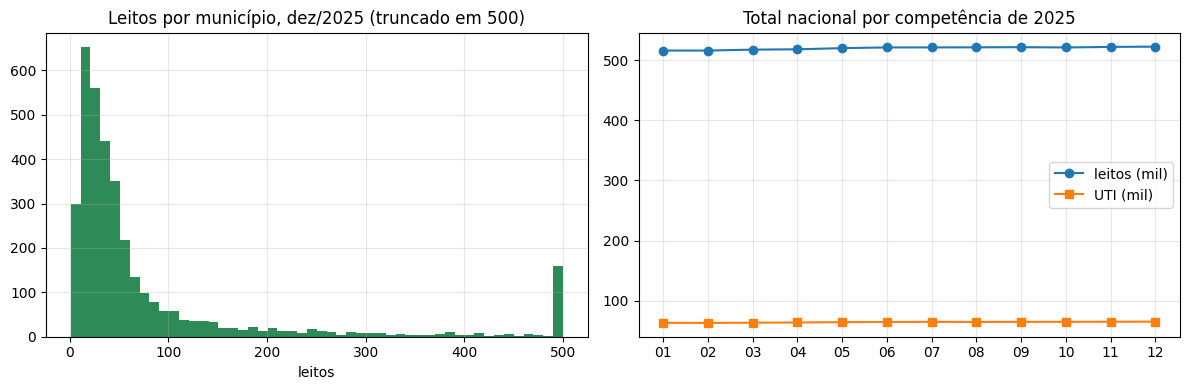

In [11]:
dez = cnes_mun[cnes_mun.competencia == 202512]
print("Distribuição por município (dez/2025):"); print(dez[["n_estabelecimentos","leitos","leitos_sus","leitos_uti"]].describe().round(1).T.to_string())
print("\nmunicípios com leitos cadastrados em dez/2025:", len(dez), "de 5.570 no Censo 2022 ->", f"{5570-len(dez):,} municípios sem estabelecimento com leitos (zero real na integração)")
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(dez.leitos.clip(upper=500), bins=50, color="seagreen"); ax[0].set_title("Leitos por município, dez/2025 (truncado em 500)"); ax[0].set_xlabel("leitos")
serie = cnes_mun.groupby("competencia")[["leitos","leitos_uti"]].sum()
ax[1].plot(range(12), serie.leitos/1e3, "o-", label="leitos (mil)"); ax[1].plot(range(12), serie.leitos_uti/1e3, "s-", label="UTI (mil)"); ax[1].set_xticks(range(12)); ax[1].set_xticklabels([str(c)[-2:] for c in serie.index]); ax[1].set_title("Total nacional por competência de 2025"); ax[1].legend()
plt.tight_layout(); plt.show()

## 9. Exportação

`cnes_municipio_2025_tratado.csv` com a estrutura desejada no plano (`cod_municipio`, `competencia`, `leitos`, `leitos_sus`, `leitos_uti`) mais `leitos_uti_sus` e `n_estabelecimentos`; e `cnes_estabelecimentos_2025_validado.csv`, o nível de estabelecimento com tipos validados e a marca de inconsistência, para rastreabilidade. Os indicadores relativos (por 10 mil ou 100 mil habitantes) serão calculados na integração, quando a população do IBGE estiver na mesma linha.

In [12]:
# ============================================================
# 9. EXPORTAÇÃO
# ============================================================
cnes_mun.to_csv(ARQ_TRATADO, index=False)
est.rename(columns=RENOMEAR)[["competencia","cod_municipio","CNES","TP_GESTAO","CO_TIPO_UNIDADE","DS_TIPO_UNIDADE","NATUREZA_JURIDICA","DESC_NATUREZA_JURIDICA"] + list(RENOMEAR.values()) + COLS_UTI_TIPO + ["flag_inconsistencia"]].to_csv(ARQ_ESTAB, index=False)
LOG["etapas"]["exportacao"] = {"linhas": int(len(cnes_mun)), "colunas": list(cnes_mun.columns), "tamanho_KB": round(ARQ_TRATADO.stat().st_size/1e3)}
LOG["executado_em"] = pd.Timestamp.now().strftime("%Y-%m-%d %H:%M")
ARQ_LOG.write_text(json.dumps(LOG, indent=2, ensure_ascii=False, default=str), encoding="utf-8")
print(json.dumps(LOG["etapas"]["exportacao"], indent=2))

{
  "linhas": 42552,
  "colunas": [
    "cod_municipio",
    "competencia",
    "n_estabelecimentos",
    "leitos",
    "leitos_sus",
    "leitos_uti",
    "leitos_uti_sus"
  ],
  "tamanho_KB": 1133
}


## 10. Resumo

In [13]:
# ============================================================
# 10. RESUMO
# ============================================================
pd.DataFrame([
    ["linhas no bruto (estabelecimento x competência)", len(leitos), ""],
    ["linhas totalmente duplicadas", int(leitos.duplicated().sum()), "nenhuma removida"],
    ["colunas no bruto / descartadas / mantidas", f"{leitos.shape[1]} / {len(COLS_DESCARTAR)} / {leitos.shape[1]-len(COLS_DESCARTAR)}", "R6"],
    ["inconsistências entre categorias (marcadas)", n_incons, "R3"],
    ["nulos nas colunas de leito", n_nulos, "R4"],
    ["linhas na saída (município x competência)", len(cnes_mun), "R5"],
    ["municípios com leitos", cnes_mun.cod_municipio.nunique(), "os demais = zero real"],
    ["competências", cnes_mun.competencia.nunique(), "202501-202512"],
], columns=["item","valor","observação"])

,item,valor,observação
0,linhas no bruto (estabelecimento x competência),86147,
1,linhas totalmente duplicadas,0,nenhuma removida
2,colunas no bruto / descartadas / mantidas,35 / 13 / 22,R6
3,inconsistências entre categorias (marcadas),0,R3
4,nulos nas colunas de leito,0,R4
5,linhas na saída (município x competência),42552,R5
6,municípios com leitos,3577,os demais = zero real
7,competências,12,202501-202512
